In [5]:
import pandas as pd
import numpy as np
# Define the path to the CSV file
csv_file_path = 'covid_fibrosis_cls.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)

# Extract the third column
third_column = df.iloc[:, 3]  # Using iloc to select the third column by index
print(third_column)
indices = third_column[third_column > 0.5].index
cls_id = np.array(indices)
print(len(cls_id))
print(cls_id)

0       0.577905
1       0.791938
2       0.022847
3       0.929515
4       0.611569
          ...   
9929    0.488979
9930    0.324828
9931    0.828348
9932    0.190247
9933    0.071730
Name: manip - fib, Length: 9934, dtype: float64
7298
[   0    1    3 ... 9924 9927 9931]


In [9]:
csv_file_path = "/media/NAS06/gavinyue/disentanglement/scripts_segmentation/classifer_result/Dice_Score.csv"
# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)
# Extract the third column
dice_noS = df.iloc[:, 4]
mask_area = df.iloc[:, 6]
print(dice_noS)
print(mask_area)

0       0.705918
1       0.653435
2       0.504448
3       0.706900
4       0.140897
          ...   
2520    0.804203
2521    0.474960
2522    0.643376
2523    0.682306
2524    0.504486
Name: Diffusion + Unet_noscale, Length: 2525, dtype: float64
0       9257
1       2591
2       6907
3       6404
4       2404
        ... 
2520    5092
2521     729
2522    4629
2523    4768
2524    5854
Name: mask_area, Length: 2525, dtype: int64


In [14]:
mask_threshold = 1500
mask_valid = mask_area > mask_threshold
print(mask_valid)

0        True
1        True
2        True
3        True
4        True
        ...  
2520     True
2521    False
2522     True
2523     True
2524     True
Name: mask_area, Length: 2525, dtype: bool


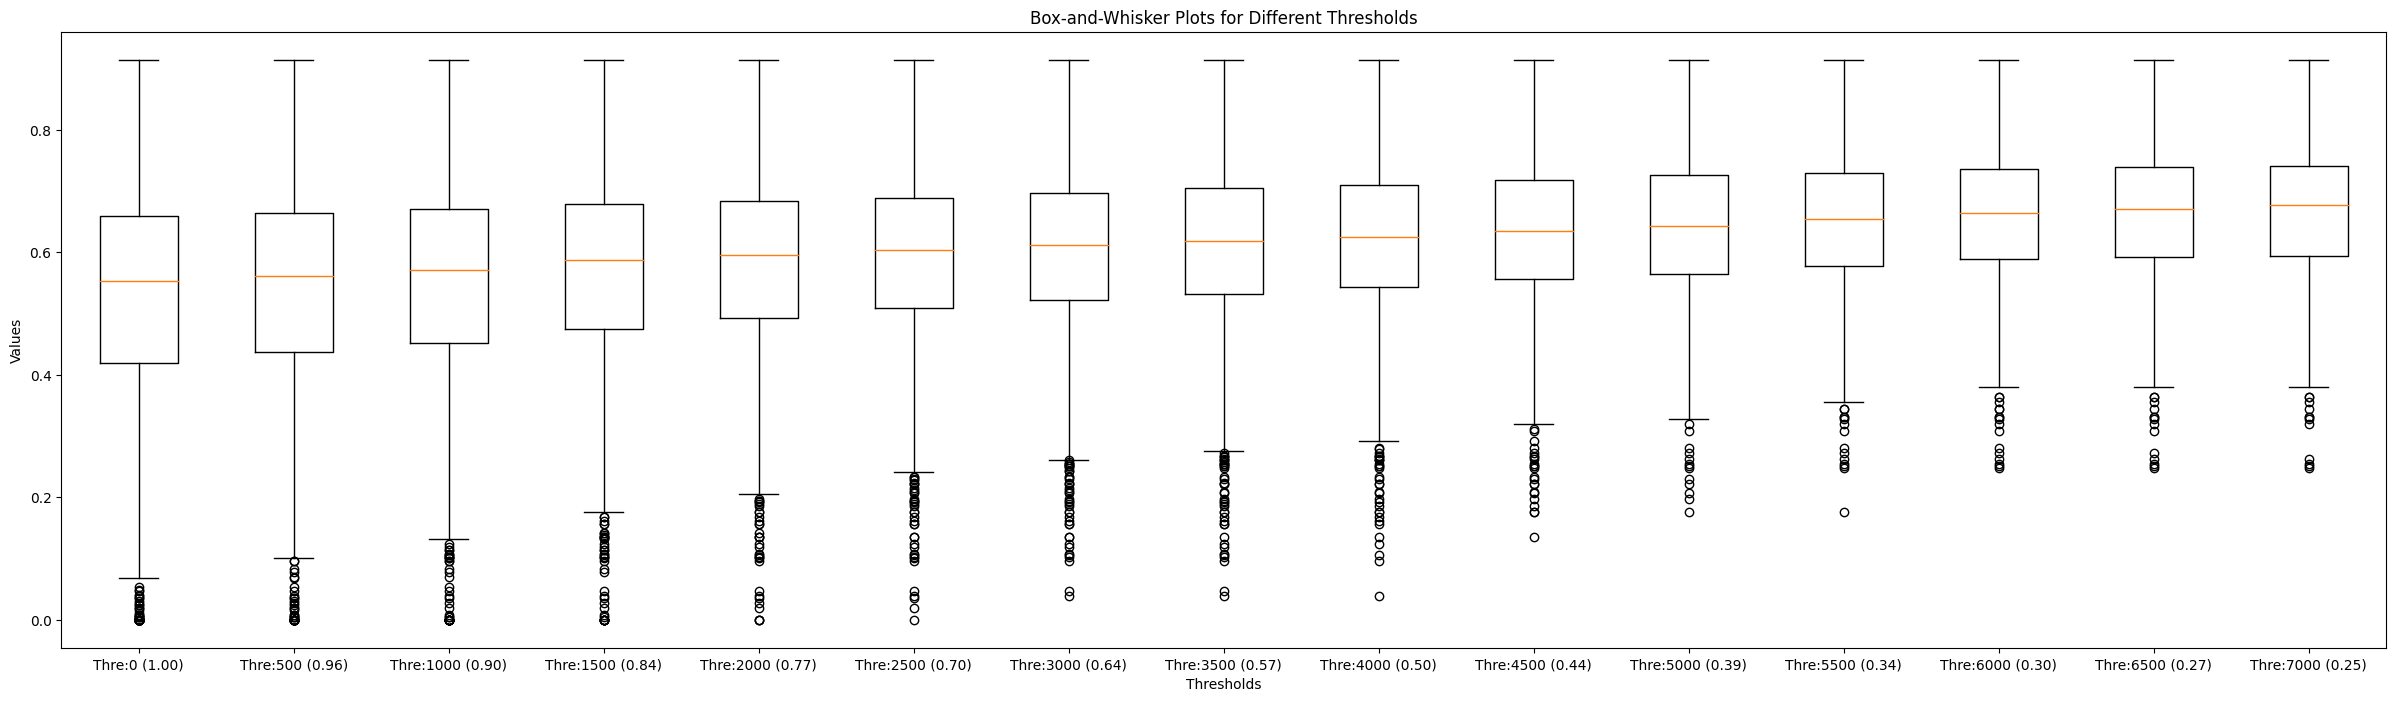

In [62]:
import matplotlib.pyplot as plt
import numpy as np

mask_area = df.iloc[:, 6]
# Initial threshold
mask_threshold = 0

# List to store data for each threshold
all_data = []
thresholds = []
thre_ratio = []

# Loop to increment the threshold and collect data
for i in range(int(7500/500)):  # Adjust the range as needed
    mask_valid = mask_area > mask_threshold
    data = np.array(dice_noS[mask_valid])
    # print(f'Threshold: {mask_threshold}')
    # print(data)
    # print(data.shape, f'ratio {len(data)/len(dice_noS)}')
    
    all_data.append(data)
    # thresholds.append(f'Threshold: {mask_threshold}')
    thre_ratio = len(data)/len(dice_noS)
    thresholds.append(f'Thre:{mask_threshold} ({thre_ratio:.2f})')
    
    # Increment the threshold
    mask_threshold += 500

# Plotting all boxplots in the same figure
plt.figure(figsize=(30, 8))
plt.boxplot(all_data, labels=thresholds)
plt.title('Box-and-Whisker Plots for Different Thresholds')
plt.ylabel('Values')
plt.xlabel('Thresholds')
plt.show()

[0.5531066060000001, 0.5626136365000001, 0.5726535915, 0.585255086, 0.5914224685, 0.5975733105000001, 0.6046511529999999, 0.6102550625000001, 0.615241885, 0.618980199, 0.6244788465, 0.633214235, 0.640484452, 0.65284878, 0.663307667]


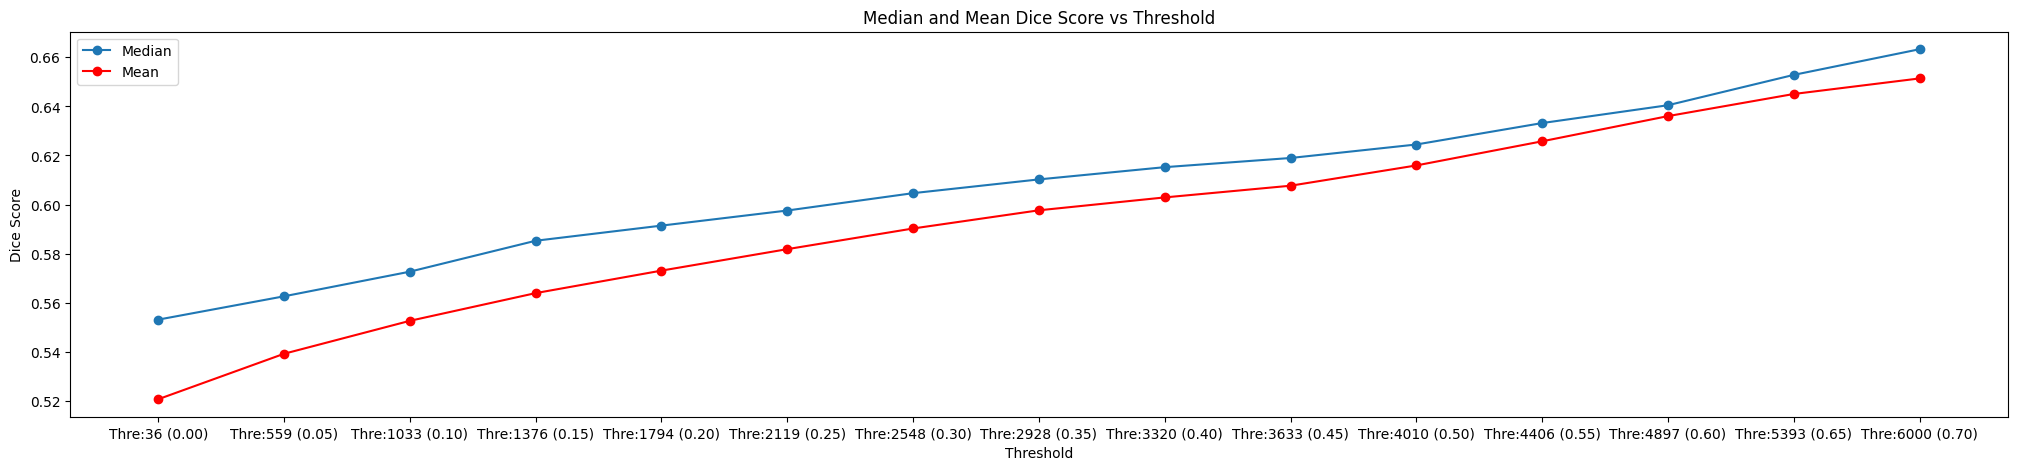

In [73]:
mask_area = df.iloc[:, 6]

# Initial threshold
thre = 0
# Sort the mask_area array
sorted_mask_area = np.sort(mask_area)

# Calculate the index for the top 10%
all_mediandata = []
all_meandata = []
all_thre = []
all_mask_threshold = []

plt.subplots(figsize=(25, 5))
# Loop to increment the threshold and collect data
for i in range(15):  # Adjust the range as needed
    top_idx = int(len(sorted_mask_area) * thre)

    mask_threshold = sorted_mask_area[top_idx]

    if mask_threshold.shape == 0:
        mask_threshold = 0
    
    mask_valid = mask_area > mask_threshold
    data = np.array(dice_noS[mask_valid])
    all_mediandata.append(np.median(data))
    all_meandata.append(np.mean(data))
    # all_thre.append(thre)
    all_thre.append(f'Thre:{mask_threshold} ({thre:.2f})')
    all_mask_threshold.append(mask_threshold)

    # Increment the threshold
    thre += 0.05
plt.plot(all_thre, all_mediandata, '-o')
plt.plot(all_thre, all_meandata, '-o',color='red')
plt.title('Median and Mean Dice Score vs Threshold')
plt.ylabel('Dice Score')
plt.xlabel('Threshold')
plt.legend(['Median', 'Mean'], loc='upper left')
print(all_mediandata)

# plt.imshow()

In [75]:
# combine two masks
csv_file_path = "/media/NAS06/gavinyue/disentanglement/scripts_segmentation/classifer_result/Dice_Score.csv"
# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)
# Extract the third column
dice_noS = df.iloc[:, 5]
mask_area = df.iloc[:, 6]

[0.5886915625, 0.5942314265, 0.602072686, 0.609764636, 0.6175197065, 0.623006374, 0.630079627, 0.6353090109999999, 0.639077723, 0.643660098, 0.6487702725, 0.656466305, 0.664833009, 0.6759471890000001, 0.683835089, 0.6902349590000001, 0.6933107975, 0.695632875, 0.6925887465, 0.6931033135]
[0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.3, 0.35, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7000000000000001, 0.7500000000000001, 0.8000000000000002, 0.8500000000000002, 0.9000000000000002, 0.9500000000000003]


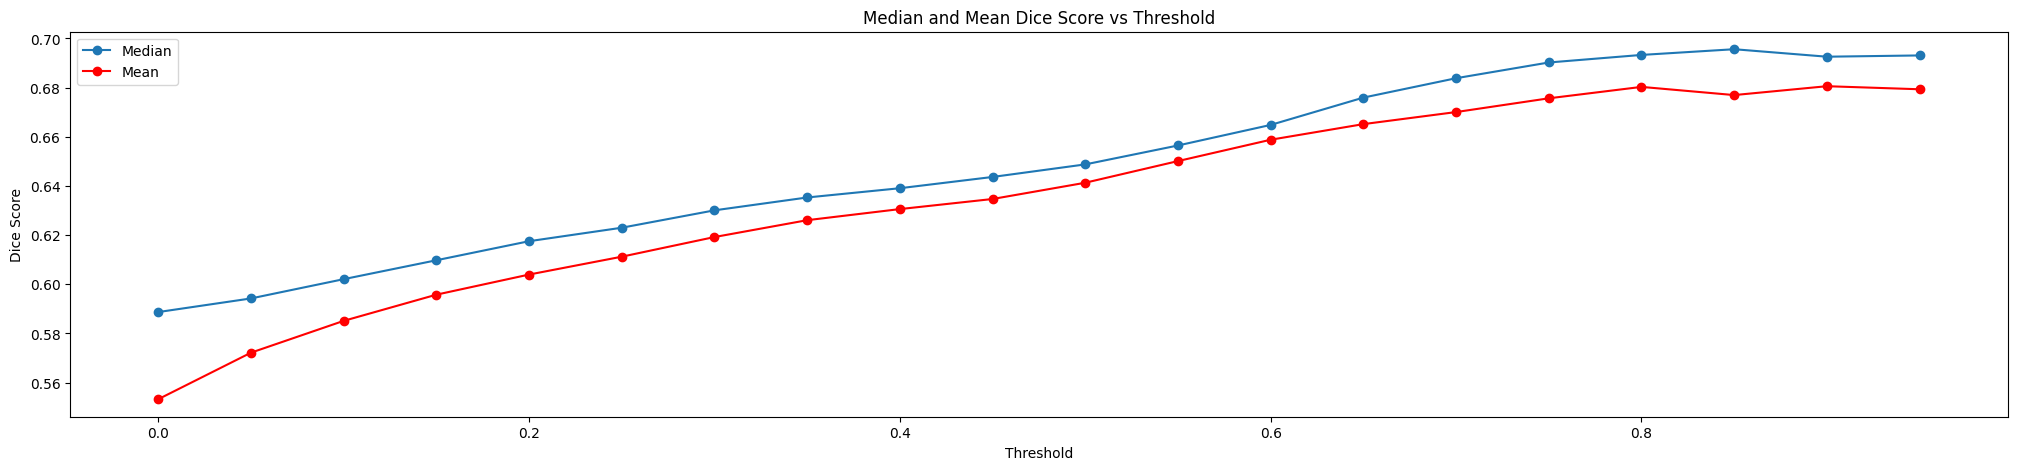

In [88]:
# Initial threshold
thre = 0
# Sort the mask_area array
sorted_mask_area = np.sort(mask_area)

# Calculate the index for the top 10%
all_mediandata = []
all_meandata = []
all_thre = []
all_mask_threshold = []

plt.subplots(figsize=(25, 5))
# Loop to increment the threshold and collect data
for i in range(20):  # Adjust the range as needed
    top_idx = int(len(sorted_mask_area) * thre)


    mask_threshold = sorted_mask_area[top_idx]

    
    mask_valid = mask_area > mask_threshold
    data = np.array(dice_noS[mask_valid])
    all_mediandata.append(np.median(data))
    all_meandata.append(np.mean(data))
    all_thre.append(thre)
    # all_thre.append(f'Thre:{mask_threshold} ({thre:.2f})')
    all_mask_threshold.append(mask_threshold)

    # Increment the threshold
    thre += 0.05
plt.plot(all_thre, all_mediandata, '-o')
plt.plot(all_thre, all_meandata, '-o',color='red')
plt.title('Median and Mean Dice Score vs Threshold')
plt.ylabel('Dice Score')
plt.xlabel('Threshold')
plt.legend(['Median', 'Mean'], loc='upper left')
print(all_mediandata)
print(all_thre)


df2 = pd.DataFrame({
    'MedianData': all_mediandata,
    'Threshold': all_thre
})

# Write the DataFrame to a CSV file
tmp_path = "/media/NAS06/gavinyue/disentanglement/scripts_segmentation/classifer_result/combine_mask_thre.csv"
df2.to_csv(tmp_path, index=False)